# Classifier Baseline

Baseline pipeline for Random Forest earthquake classification with configurable threshold strategy on test metrics.

## 1) Setup

In [1]:
import os
import sys
import json
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)

from src.utils.runtime_utils import resolve_project_root

PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.preparation import prepare_data_rf
from config.config_loader import load_rf_config
from src.utils.metrics import (
    classification_metrics,
    plot_and_save_pr_curve,
    plot_and_save_confusion_matrix,
)
from src.utils.bootstrap_ci import (
    SamplingMethod,
    bootstrap_multi_model_curve_ci,
    bootstrap_multi_model_metric_ci,
)
from src.utils.bootstrap_presets import PairedBootstrapPreset

print(f'PROJECT_ROOT: {PROJECT_ROOT}')


PROJECT_ROOT: /root/autodl-tmp/em_eqf


## 2) Config

In [2]:
args = load_rf_config(PROJECT_ROOT)
BASE_DIR = PROJECT_ROOT / 'data' / args.dataset
print(f'Dataset: {args.dataset}')
print(f'Save dir: {args.save_dir}')

Dataset: ChuanDian
Save dir: /root/autodl-tmp/em_eqf/checkpoints/rf_93e06b90


## 3) Data Preparation

In [3]:
df, features_df, x_train, x_val, x_test, y_train, y_val, y_test = prepare_data_rf(args, BASE_DIR)

print(f'features_df columns: {len(features_df.columns)}')
print(f"Mag_max mean: {features_df['Mag_max'].mean():.4f}")

[Train] positive: 390 | negative: 830 | total: 1220
[Train] positive ratio: 0.320 | negative ratio: 0.680
[Validation] positive: 62 | negative: 90 | total: 152
[Validation] positive ratio: 0.408 | negative ratio: 0.592
[Test] positive: 19 | negative: 135 | total: 154
[Test] positive ratio: 0.123 | negative ratio: 0.877
features_df columns: 23
Mag_max mean: 5.3123


In [4]:
features_df['T_elaps6.5'].notna().sum()

np.int64(139)

In [5]:
np.isnan(x_train).any(), np.isnan(x_val).any(), np.isnan(x_test).any()

(np.True_, np.True_, np.True_)

## 4) Train Random Forest

In [6]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=50,
    class_weight='balanced',
)
rf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=50)

## 5) ROC Curve

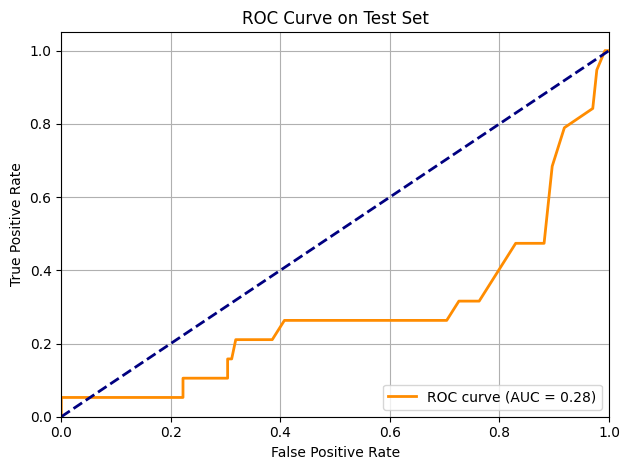

In [7]:
y_prob = rf.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(args.save_dir, 'roc_curve.png'))
plt.show()

## 6) Metrics With Threshold Switch


Validation metrics:
{'precision': 0.7432432432432432, 'recall': 0.8870967741935484, 'f1': 0.8088235294117647, 'auc': 0.8829749103942651, 'pr_auc': 0.8551993417911165, 'fpr': 0.2111111111111111, 'tpr': 0.8870967741935484, 'R': 0.6759856630824372, 'conf': 1.0, 'threshold': 0.17}

Test metrics:
{'precision': 0.12418300653594772, 'recall': 1.0, 'f1': 0.22093023255813954, 'auc': 0.28479532163742693, 'pr_auc': 0.13983515376983674, 'fpr': 0.9925925925925926, 'tpr': 1.0, 'R': 0.12418300653594772, 'conf': 2.0847150504513495e-264, 'threshold': 0.01, 'threshold_mode': 'auto', 'val_threshold': 0.17}


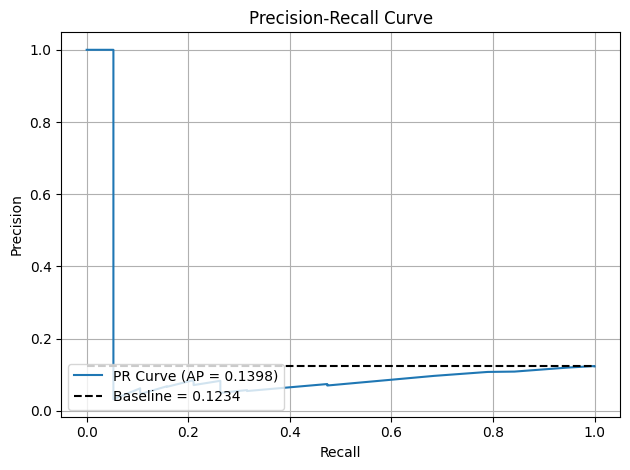

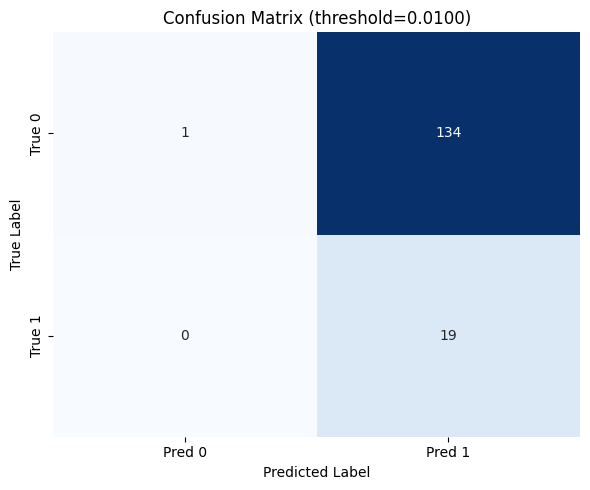

In [8]:
# For RF probabilities, keep apply_sigmoid=False.
# Supported modes:
# - 'auto'          : same as classification_metrics(y_test, y_prob)
# - 'val_threshold' : same as classification_metrics(y_test, y_prob, val_metrics['threshold'])
TEST_THRESHOLD_MODE = 'auto'  # 'auto' | 'val_threshold'

y_val_prob = rf.predict_proba(x_val)[:, 1]
val_metrics = classification_metrics(y_val, y_val_prob, apply_sigmoid=False)

val_metrics_path = os.path.join(args.save_dir, 'val_metrics.json')
with open(val_metrics_path, 'w') as f:
    json.dump(val_metrics, f, indent=2)

if TEST_THRESHOLD_MODE == 'auto':
    # test_metrics = classification_metrics(y_test, y_prob)
    test_metrics = classification_metrics(y_test, y_prob, apply_sigmoid=False)
elif TEST_THRESHOLD_MODE == 'val_threshold':
    # test_metrics = classification_metrics(y_test, y_prob, val_metrics['threshold'])
    test_metrics = classification_metrics(
        y_test,
        y_prob,
        threshold=val_metrics['threshold'],
        apply_sigmoid=False,
    )
else:
    raise ValueError(f'Unknown TEST_THRESHOLD_MODE: {TEST_THRESHOLD_MODE}')

if 'recall' in test_metrics and 'precision' in test_metrics:
    test_metrics['R'] = test_metrics['recall'] * test_metrics['precision']

test_metrics['threshold_mode'] = TEST_THRESHOLD_MODE
test_metrics['val_threshold'] = float(val_metrics['threshold'])

test_metrics_path = os.path.join(args.save_dir, 'test_metrics.json')
with open(test_metrics_path, 'w') as f:
    json.dump(test_metrics, f, indent=2)

print('Validation metrics:')
print(val_metrics)
print()
print('Test metrics:')
print(test_metrics)

plot_and_save_pr_curve(
    y_test,
    y_prob,
    pr_auc_value=float(test_metrics['pr_auc']),
    save_dir=args.save_dir,
    filename='pr_curve.png',
)

plot_and_save_confusion_matrix(
    y_test,
    y_prob,
    threshold=float(test_metrics['threshold']),
    save_dir=args.save_dir,
    filename='confusion_matrix.png',
    apply_sigmoid=False,
)


In [9]:
test_metrics

{'precision': 0.12418300653594772,
 'recall': 1.0,
 'f1': 0.22093023255813954,
 'auc': 0.28479532163742693,
 'pr_auc': 0.13983515376983674,
 'fpr': 0.9925925925925926,
 'tpr': 1.0,
 'R': 0.12418300653594772,
 'conf': 2.0847150504513495e-264,
 'threshold': 0.01,
 'threshold_mode': 'auto',
 'val_threshold': 0.17}

## 7) Feature Importance


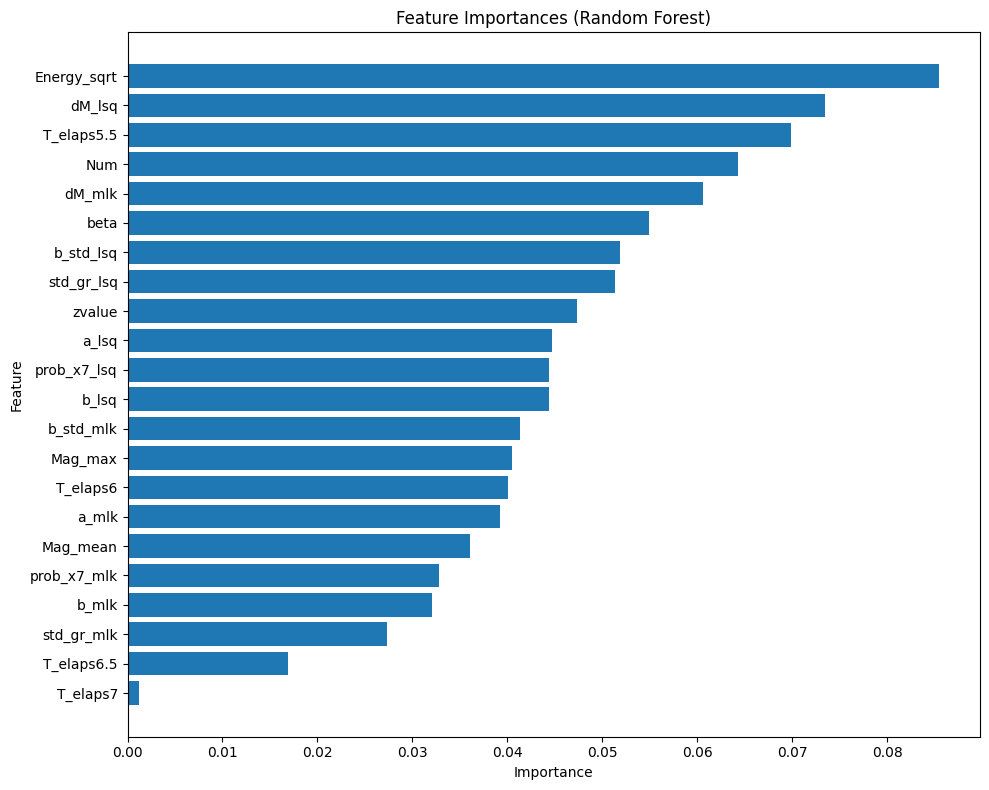

In [10]:
importances = rf.feature_importances_
feature_names = args.feature_cols

indices = np.argsort(importances)[::-1]
sorted_names = [feature_names[int(i)] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_importances)), sorted_importances, align='center')
plt.yticks(range(len(sorted_importances)), sorted_names)
plt.ylabel('Feature')
plt.xlabel('Importance')
plt.title('Feature Importances (Random Forest)')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.savefig(os.path.join(args.save_dir, 'feature_importances.png'))
plt.show()

## 8) Compare RF vs Selected `clf_mixer_attnpl_t` (ROC + PR)


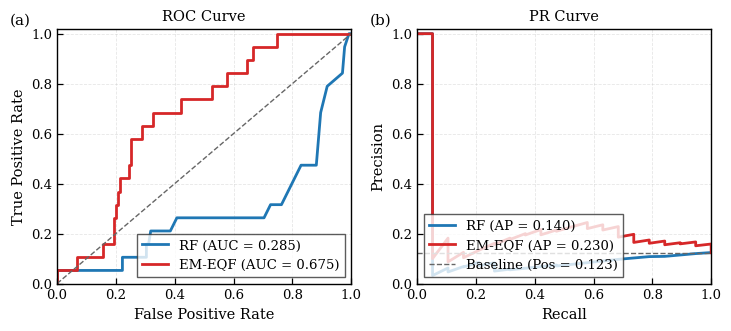

Selected mixer checkpoint: /root/autodl-tmp/em_eqf/experiments/clf_grid_r_2/runs/tf_90_mf_5p5_seed_1/best_model_1.pth
Saved comparison figure (PDF): /root/autodl-tmp/em_eqf/notebooks/figs/clf/roc_pr_Mf5.5_Twindow180_Tfore90.pdf


In [11]:
# Select clf_mixer_attnpl_t checkpoint by (Mf, Tfore) from RF config.
CLF_MIXER_CKPT_MAP = {
    (4.0, 10): 'experiments/clf_grid_r_2/runs/tf_10_mf_4p0_seed_1',
    (4.5, 20): 'experiments/clf_grid_r_2/runs/tf_20_mf_4p5_seed_1',
    (4.5, 30): 'experiments/clf_grid_r_2/runs/tf_30_mf_4p5_seed_1',
    (5.0, 60): 'experiments/clf_grid_r_2/runs/tf_60_mf_5p0_seed_1',
    (5.5, 90): 'experiments/clf_grid_r_2/runs/tf_90_mf_5p5_seed_1',
}

ckpt_key = (float(args.Mf), int(args.Tfore))
if ckpt_key not in CLF_MIXER_CKPT_MAP:
    available = ', '.join(str(k) for k in sorted(CLF_MIXER_CKPT_MAP.keys()))
    raise KeyError(f'No clf_mixer_attnpl_t checkpoint mapping for Mf/Tfore={ckpt_key}. Available: {available}')

def resolve_clf_mixer_checkpoint_path(path_like: str) -> Path:
    path = Path(path_like).expanduser()
    if not path.is_absolute():
        path = PROJECT_ROOT / path

    if path.is_dir():
        path = path / 'best_model_1.pth'
    elif path.suffix.lower() != '.pth':
        ckpt_dir = PROJECT_ROOT / 'checkpoints' / Path(path_like)
        if ckpt_dir.is_dir():
            path = ckpt_dir / 'best_model_1.pth'

    path = path.resolve()
    if not path.exists():
        raise FileNotFoundError(f'Checkpoint not found: {path}')
    return path


SELECTED_CLF_MIXER_CKPT = resolve_clf_mixer_checkpoint_path(CLF_MIXER_CKPT_MAP[ckpt_key])
CLF_BATCH_SIZE = 64
CLF_DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

from src.data.preparation import prepare_data
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint, load_model_from_checkpoint
import src.utils.viz_analysis as analysis


def load_clf_mixer_test_scores(checkpoint_path: Path):
    check_point = torch.load(checkpoint_path, map_location=CLF_DEVICE, weights_only=False)
    clf_args = load_args_from_checkpoint(None, check_point)

    model_builder = ModelBuilder.by_name(clf_args.model.lower())()
    model = model_builder(clf_args, CLF_DEVICE)
    model, _, _ = load_model_from_checkpoint(model, check_point)
    model.eval()

    clf_args.use_sampler = False
    clf_args.batch_size = CLF_BATCH_SIZE

    base_dir = PROJECT_ROOT / 'data' / clf_args.dataset
    _, _, _, test_loader, _ = prepare_data(args=clf_args, base_dir=str(base_dir))

    y_logits, y_true, _ = analysis.predict_all(
        model,
        test_loader,
        CLF_DEVICE,
        return_X=False,
    )

    logits_np = np.asarray(y_logits, dtype=np.float64)
    y_prob = 1.0 / (1.0 + np.exp(-np.clip(logits_np, -60.0, 60.0)))
    y_true = np.asarray(y_true).astype(int)
    return y_true, y_prob, clf_args


y_test_mixer, y_prob_mixer, clf_args = load_clf_mixer_test_scores(SELECTED_CLF_MIXER_CKPT)

# RF curves
rf_fpr, rf_tpr, _ = roc_curve(y_test, y_prob)
rf_roc_auc = auc(rf_fpr, rf_tpr)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, y_prob)
rf_pr_auc = average_precision_score(y_test, y_prob)

# Mixer curves
mixer_fpr, mixer_tpr, _ = roc_curve(y_test_mixer, y_prob_mixer)
mixer_roc_auc = auc(mixer_fpr, mixer_tpr)
mixer_precision, mixer_recall, _ = precision_recall_curve(y_test_mixer, y_prob_mixer)
mixer_pr_auc = average_precision_score(y_test_mixer, y_prob_mixer)

same_labels = (
    len(y_test) == len(y_test_mixer)
    and np.array_equal(np.asarray(y_test).astype(int), y_test_mixer)
)
if not same_labels:
    print('[Warn] RF and mixer test labels are not identical in this run. Curves are still plotted, but compare with caution.')

# Publication-style plotting
plot_rc = {
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10.5,
    'axes.labelsize': 10.5,
    'axes.titlesize': 10.5,
    'legend.fontsize': 9.5,
    'xtick.labelsize': 9.5,
    'ytick.labelsize': 9.5,
    'axes.linewidth': 1.0,
}

with plt.rc_context(plot_rc):
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2), constrained_layout=True)

    color_rf = '#1f77b4'
    color_em = '#d62728'
    positive_rate = float(np.mean(np.asarray(y_test).astype(int)))

    # (a) ROC
    axes[0].plot(rf_fpr, rf_tpr, color=color_rf, lw=2.0, label=f'RF (AUC = {rf_roc_auc:.3f})')
    axes[0].plot(mixer_fpr, mixer_tpr, color=color_em, lw=2.0, label=f'EM-EQF (AUC = {mixer_roc_auc:.3f})')
    axes[0].plot([0, 1], [0, 1], color='0.4', lw=1.0, linestyle='--')
    axes[0].set_xlim(0.0, 1.0)
    axes[0].set_ylim(0.0, 1.02)
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve')
    axes[0].grid(True, linestyle='--', linewidth=0.6, alpha=0.3)
    axes[0].legend(loc='lower right', frameon=True, fancybox=False, edgecolor='0.2')

    # (b) PR
    axes[1].plot(rf_recall, rf_precision, color=color_rf, lw=2.0, label=f'RF (AP = {rf_pr_auc:.3f})')
    axes[1].plot(mixer_recall, mixer_precision, color=color_em, lw=2.0, label=f'EM-EQF (AP = {mixer_pr_auc:.3f})')
    axes[1].hlines(
        y=positive_rate,
        xmin=0.0,
        xmax=1.0,
        colors='0.4',
        linestyles='--',
        linewidth=1.0,
        label=f'Baseline (Pos = {positive_rate:.3f})',
    )
    axes[1].set_xlim(0.0, 1.0)
    axes[1].set_ylim(0.0, 1.02)
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('PR Curve')
    axes[1].grid(True, linestyle='--', linewidth=0.6, alpha=0.3)
    axes[1].legend(loc='lower left', frameon=True, fancybox=False, edgecolor='0.2')

    for ax in axes:
        ax.tick_params(direction='in', length=4, width=0.9)

    # panel labels for paper figures
    axes[0].text(-0.16, 1.06, '(a)', transform=axes[0].transAxes, va='top', ha='left', fontsize=11)
    axes[1].text(-0.16, 1.06, '(b)', transform=axes[1].transAxes, va='top', ha='left', fontsize=11)

    fig_dir = PROJECT_ROOT / 'notebooks' / 'figs' / 'clf'
    fig_dir.mkdir(parents=True, exist_ok=True)

    suffix = f"Mf{args.Mf}_Twindow{args.Twindow}_Tfore{args.Tfore}"
    fig_stem = f"roc_pr_{suffix}"
    combined_plot_pdf_path = str(fig_dir / f"{fig_stem}.pdf")

    plt.savefig(combined_plot_pdf_path, bbox_inches='tight')
    plt.show()

print(f'Selected mixer checkpoint: {SELECTED_CLF_MIXER_CKPT}')
print(f'Saved comparison figure (PDF): {combined_plot_pdf_path}')


## 9) Multi-Window RF vs EM-EQF in One Figure (ROC + PR)

Paper-oriented design:
- color encodes window `(Mf, Tfore)`
- line style encodes model (`RF`: dashed, `EM-EQF`: solid)
- one shared figure with two panels: ROC and PR


[Train] positive: 594 | negative: 576 | total: 1170
[Train] positive ratio: 0.508 | negative ratio: 0.492
[Validation] positive: 107 | negative: 39 | total: 146
[Validation] positive ratio: 0.733 | negative ratio: 0.267
[Test] positive: 79 | negative: 68 | total: 147
[Test] positive ratio: 0.537 | negative ratio: 0.463
[Train] positive: 528 | negative: 646 | total: 1174
[Train] positive ratio: 0.450 | negative ratio: 0.550
[Validation] positive: 60 | negative: 86 | total: 146
[Validation] positive ratio: 0.411 | negative ratio: 0.589
[Test] positive: 35 | negative: 113 | total: 148
[Test] positive ratio: 0.236 | negative ratio: 0.764
[Train] positive: 706 | negative: 438 | total: 1144
[Train] positive ratio: 0.617 | negative ratio: 0.383
[Validation] positive: 83 | negative: 60 | total: 143
[Validation] positive ratio: 0.580 | negative ratio: 0.420
[Test] positive: 47 | negative: 96 | total: 143
[Test] positive ratio: 0.329 | negative ratio: 0.671
[Train] positive: 673 | negative: 494 

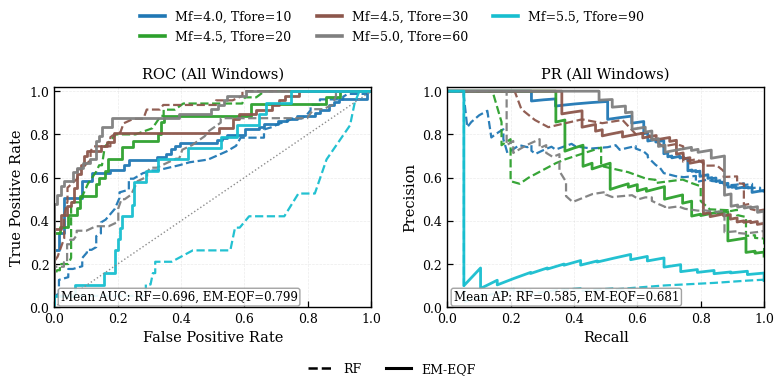

Saved multi-window comparison figure (PDF): /root/autodl-tmp/em_eqf/notebooks/figs/clf/roc_pr_multi_windows_rf_vs_em_eqf.pdf
Saved multi-window comparison figure (PNG): /root/autodl-tmp/em_eqf/notebooks/figs/clf/roc_pr_multi_windows_rf_vs_em_eqf.png


In [12]:
from matplotlib.lines import Line2D
from omegaconf import OmegaConf

MULTI_WINDOWS = [
    (4.0, 10),
    (4.5, 20),
    (4.5, 30),
    (5.0, 60),
    (5.5, 90),
]
MULTI_WINDOWS = [w for w in MULTI_WINDOWS if w in CLF_MIXER_CKPT_MAP]


def clone_rf_args_for_window(base_args, mf: float, tfore: int):
    cfg_dict = OmegaConf.to_container(base_args, resolve=True)
    cfg = OmegaConf.create(cfg_dict)
    cfg.Mf = float(mf)
    cfg.Tfore = int(tfore)
    return cfg


def evaluate_window_pair(mf: float, tfore: int):
    local_args = clone_rf_args_for_window(args, mf, tfore)
    local_base_dir = PROJECT_ROOT / 'data' / local_args.dataset

    # Reuse RF pipeline per window
    _, _, x_train_w, _, x_test_w, y_train_w, _, y_test_rf = prepare_data_rf(local_args, local_base_dir)
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced',
    )
    rf_model.fit(x_train_w, y_train_w)
    y_prob_rf = rf_model.predict_proba(x_test_w)[:, 1]
    y_test_rf = np.asarray(y_test_rf).astype(int)

    # Load selected EM-EQF checkpoint for this window
    ckpt_dir_name = CLF_MIXER_CKPT_MAP[(float(mf), int(tfore))]
    ckpt_path = resolve_clf_mixer_checkpoint_path(ckpt_dir_name)
    y_test_em, y_prob_em, _ = load_clf_mixer_test_scores(ckpt_path)

    same_labels = (
        len(y_test_rf) == len(y_test_em)
        and np.array_equal(y_test_rf, np.asarray(y_test_em).astype(int))
    )
    if not same_labels:
        print(f'[Warn] Labels mismatch at window (Mf={mf}, Tfore={tfore}). Compare with caution.')

    rf_fpr, rf_tpr, _ = roc_curve(y_test_rf, y_prob_rf)
    rf_auc = auc(rf_fpr, rf_tpr)
    rf_precision, rf_recall, _ = precision_recall_curve(y_test_rf, y_prob_rf)
    rf_ap = average_precision_score(y_test_rf, y_prob_rf)

    em_fpr, em_tpr, _ = roc_curve(y_test_em, y_prob_em)
    em_auc = auc(em_fpr, em_tpr)
    em_precision, em_recall, _ = precision_recall_curve(y_test_em, y_prob_em)
    em_ap = average_precision_score(y_test_em, y_prob_em)

    return {
        'Mf': float(mf),
        'Tfore': int(tfore),
        'y_test_rf': y_test_rf,
        'y_prob_rf': y_prob_rf,
        'rf_fpr': rf_fpr,
        'rf_tpr': rf_tpr,
        'rf_recall': rf_recall,
        'rf_precision': rf_precision,
        'rf_auc': float(rf_auc),
        'rf_ap': float(rf_ap),
        'y_test_em': np.asarray(y_test_em).astype(int),
        'y_prob_em': y_prob_em,
        'em_fpr': em_fpr,
        'em_tpr': em_tpr,
        'em_recall': em_recall,
        'em_precision': em_precision,
        'em_auc': float(em_auc),
        'em_ap': float(em_ap),
    }


multi_results = [evaluate_window_pair(mf, tf) for (mf, tf) in MULTI_WINDOWS]

for r in multi_results:
    print(
        f"Window Mf={r['Mf']:.1f}, Tfore={r['Tfore']:>3d} | "
        f"RF AUC/AP={r['rf_auc']:.3f}/{r['rf_ap']:.3f} | "
        f"EM-EQF AUC/AP={r['em_auc']:.3f}/{r['em_ap']:.3f}"
    )

mean_rf_auc = float(np.mean([r['rf_auc'] for r in multi_results]))
mean_rf_ap = float(np.mean([r['rf_ap'] for r in multi_results]))
mean_em_auc = float(np.mean([r['em_auc'] for r in multi_results]))
mean_em_ap = float(np.mean([r['em_ap'] for r in multi_results]))

plot_rc_multi = {
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10.5,
    'axes.labelsize': 10.5,
    'axes.titlesize': 10.5,
    'legend.fontsize': 9.0,
    'xtick.labelsize': 9.0,
    'ytick.labelsize': 9.0,
    'axes.linewidth': 1.0,
}

colors = plt.cm.tab10(np.linspace(0.0, 1.0, len(multi_results)))

with plt.rc_context(plot_rc_multi):
    fig, axes = plt.subplots(1, 2, figsize=(7.8, 3.8), constrained_layout=False)

    # Curves: same color for same window, dashed/solid for model
    for i, r in enumerate(multi_results):
        c = colors[i]
        axes[0].plot(r['rf_fpr'], r['rf_tpr'], color=c, lw=1.6, linestyle='--', alpha=0.95)
        axes[0].plot(r['em_fpr'], r['em_tpr'], color=c, lw=2.0, linestyle='-', alpha=0.95)

        axes[1].plot(r['rf_recall'], r['rf_precision'], color=c, lw=1.6, linestyle='--', alpha=0.95)
        axes[1].plot(r['em_recall'], r['em_precision'], color=c, lw=2.0, linestyle='-', alpha=0.95)

    axes[0].plot([0, 1], [0, 1], color='0.55', lw=1.0, linestyle=':')
    axes[0].set_xlim(0.0, 1.0)
    axes[0].set_ylim(0.0, 1.02)
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC (All Windows)')
    axes[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.25)

    axes[1].set_xlim(0.0, 1.0)
    axes[1].set_ylim(0.0, 1.02)
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('PR (All Windows)')
    axes[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.25)

    axes[0].text(
        0.02,
        0.03,
        f"Mean AUC: RF={mean_rf_auc:.3f}, EM-EQF={mean_em_auc:.3f}",
        transform=axes[0].transAxes,
        fontsize=8.6,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='0.6', alpha=0.9),
    )
    axes[1].text(
        0.02,
        0.03,
        f"Mean AP: RF={mean_rf_ap:.3f}, EM-EQF={mean_em_ap:.3f}",
        transform=axes[1].transAxes,
        fontsize=8.6,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='0.6', alpha=0.9),
    )

    for ax in axes:
        ax.tick_params(direction='in', length=4, width=0.9)

    # Figure-level legends: model (line style) + window (color)
    model_handles = [
        Line2D([0], [0], color='black', lw=1.8, linestyle='--', label='RF'),
        Line2D([0], [0], color='black', lw=2.2, linestyle='-', label='EM-EQF'),
    ]
    window_handles = [
        Line2D(
            [0], [0], color=colors[i], lw=2.6,
            label=f"Mf={r['Mf']:.1f}, Tfore={r['Tfore']}"
        )
        for i, r in enumerate(multi_results)
    ]

    fig.legend(handles=window_handles, loc='upper center', ncol=min(3, len(window_handles)), frameon=False)
    fig.legend(handles=model_handles, loc='lower center', ncol=2, frameon=False)
    fig.subplots_adjust(top=0.78, bottom=0.20, left=0.08, right=0.99, wspace=0.24)

    fig_dir = PROJECT_ROOT / 'notebooks' / 'figs' / 'clf'
    fig_dir.mkdir(parents=True, exist_ok=True)
    multi_fig_pdf_path = str(fig_dir / 'roc_pr_multi_windows_rf_vs_em_eqf.pdf')
    multi_fig_png_path = str(fig_dir / 'roc_pr_multi_windows_rf_vs_em_eqf.png')
    plt.savefig(multi_fig_pdf_path, bbox_inches='tight')
    plt.savefig(multi_fig_png_path, dpi=600, bbox_inches='tight')
    plt.show()

print(f'Saved multi-window comparison figure (PDF): {multi_fig_pdf_path}')
print(f'Saved multi-window comparison figure (PNG): {multi_fig_png_path}')


## 10) Separate ROC/PR Figures (2 x 3 Subplots)

If the overlaid curves are too dense, use this faceted layout:
- each row = one window `(Mf, Tfore)`
- left column = ROC, right column = PR
- total subplots = `len(MULTI_WINDOWS) * 2` (can be > 2)


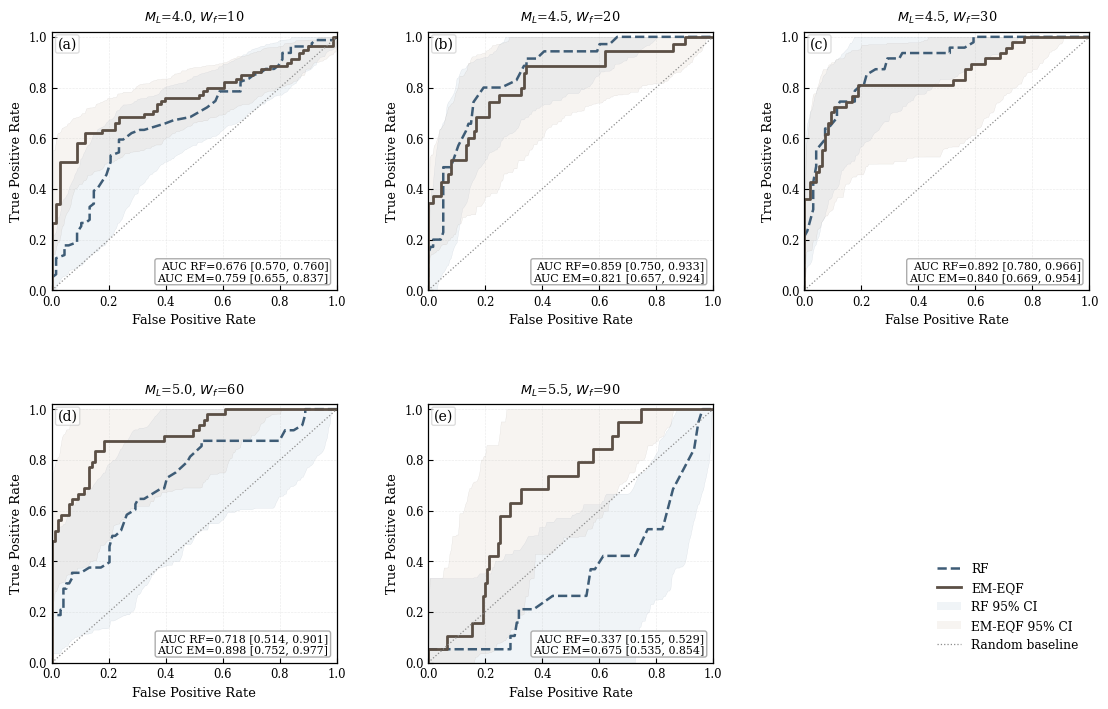

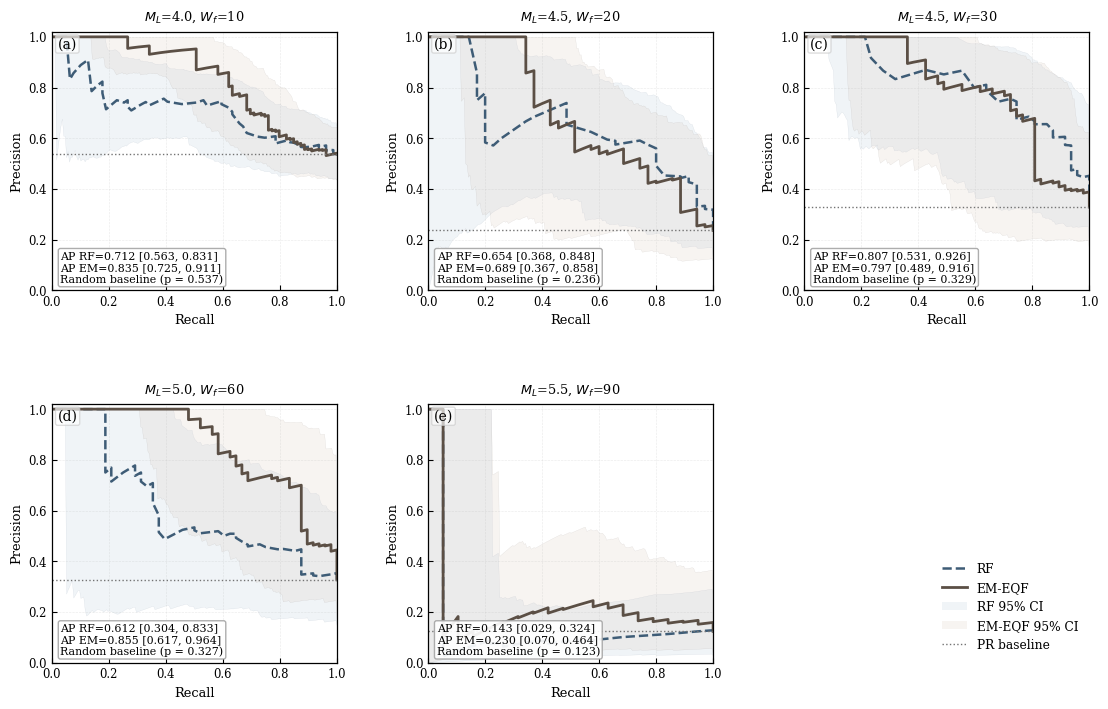

Saved ROC faceted figure (PDF): /root/autodl-tmp/em_eqf/notebooks/figs/clf/roc_facet_windows_rf_vs_em_eqf_2x3.pdf
Saved ROC faceted figure (PNG): /root/autodl-tmp/em_eqf/notebooks/figs/clf/roc_facet_windows_rf_vs_em_eqf_2x3.png
Saved PR faceted figure (PDF): /root/autodl-tmp/em_eqf/notebooks/figs/clf/pr_facet_windows_rf_vs_em_eqf_2x3.pdf
Saved PR faceted figure (PNG): /root/autodl-tmp/em_eqf/notebooks/figs/clf/pr_facet_windows_rf_vs_em_eqf_2x3.png


In [13]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Reuse multi_results from Section 9. If Section 9 was not run, build it here.
if 'multi_results' not in globals() or len(multi_results) == 0:
    multi_results = [evaluate_window_pair(mf, tf) for (mf, tf) in MULTI_WINDOWS]


plot_results = list(multi_results)
n_rows, n_cols = 2, 3
max_panels = n_rows * n_cols
if len(plot_results) > max_panels:
    print(f'[Warn] {len(plot_results)} windows provided, only first {max_panels} are plotted.')
    plot_results = plot_results[:max_panels]

panel_labels = [f'({chr(ord("a") + i)})' for i in range(max_panels)]

facet_rc = {
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9.6,
    'axes.labelsize': 9.4,
    'legend.fontsize': 8.8,
    'xtick.labelsize': 8.4,
    'ytick.labelsize': 8.4,
    'axes.linewidth': 0.9,
}

# Muted colors: keep visual contrast without being too colorful.
color_rf = '#3E5C76'
color_em = '#5B4F45'
ci_color_rf = '#AFC2D6'
ci_color_em = '#D7C4B6'
baseline_color = '0.45'
ci_alpha = 0.18

# Bootstrap setup: switch between IID and block bootstrap.
BOOTSTRAP_SAMPLING_METHOD: SamplingMethod = 'block'  # set to 'block' for block-bootstrap
BOOTSTRAP_PRESET = PairedBootstrapPreset(
    sampling=BOOTSTRAP_SAMPLING_METHOD,
    ci=(2.5, 97.5),
    n_resamples_curve=400,
    n_resamples_metric=800,
    block_size=8,
    circular_block=True,
)


# Pre-compute bootstrap CI once per window using paired indices across models.
ci_cache = []
for i, r in enumerate(plot_results):
    y_test_rf = np.asarray(r['y_test_rf']).astype(int).reshape(-1)
    y_test_em = np.asarray(r['y_test_em']).astype(int).reshape(-1)
    if y_test_rf.shape[0] != y_test_em.shape[0] or not np.array_equal(y_test_rf, y_test_em):
        raise ValueError(
            f"Paired bootstrap requires identical labels. Got mismatch at window (Mf={r['Mf']}, Tfore={r['Tfore']})."
        )
    y_true = y_test_rf

    roc_result = bootstrap_multi_model_curve_ci(
        y_true=y_true,
        model_predictions={'RF': r['y_prob_rf'], 'EM-EQF': r['y_prob_em']},
        curve='roc',
        config=BOOTSTRAP_PRESET.curve_config(seed=100 + i),
    )
    pr_result = bootstrap_multi_model_curve_ci(
        y_true=y_true,
        model_predictions={'RF': r['y_prob_rf'], 'EM-EQF': r['y_prob_em']},
        curve='pr',
        config=BOOTSTRAP_PRESET.curve_config(seed=300 + i),
    )

    auc_result = bootstrap_multi_model_metric_ci(
        y_true=y_true,
        model_predictions={'RF': r['y_prob_rf'], 'EM-EQF': r['y_prob_em']},
        metric='auc',
        config=BOOTSTRAP_PRESET.metric_config(seed=500 + i),
    )
    ap_result = bootstrap_multi_model_metric_ci(
        y_true=y_true,
        model_predictions={'RF': r['y_prob_rf'], 'EM-EQF': r['y_prob_em']},
        metric='ap',
        config=BOOTSTRAP_PRESET.metric_config(seed=700 + i),
    )

    ci_cache.append(
        {
            'roc_rf': (roc_result.grid, roc_result.model_results['RF'].ci_low, roc_result.model_results['RF'].ci_high),
            'roc_em': (roc_result.grid, roc_result.model_results['EM-EQF'].ci_low, roc_result.model_results['EM-EQF'].ci_high),
            'pr_rf': (pr_result.grid, pr_result.model_results['RF'].ci_low, pr_result.model_results['RF'].ci_high),
            'pr_em': (pr_result.grid, pr_result.model_results['EM-EQF'].ci_low, pr_result.model_results['EM-EQF'].ci_high),
            'auc_ci_rf': (auc_result.model_results['RF'].ci_low, auc_result.model_results['RF'].ci_high),
            'auc_ci_em': (auc_result.model_results['EM-EQF'].ci_low, auc_result.model_results['EM-EQF'].ci_high),
            'ap_ci_rf': (ap_result.model_results['RF'].ci_low, ap_result.model_results['RF'].ci_high),
            'ap_ci_em': (ap_result.model_results['EM-EQF'].ci_low, ap_result.model_results['EM-EQF'].ci_high),
        }
    )


def plot_roc_grid():
    with plt.rc_context(facet_rc):
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(11.4, 7.6), squeeze=False, constrained_layout=False)
        axes_flat = axes.ravel()

        for i, ax in enumerate(axes_flat):
            if i >= len(plot_results):
                ax.axis('off')
                continue

            r = plot_results[i]
            grid_roc, rf_roc_lo, rf_roc_hi = ci_cache[i]['roc_rf']
            _, em_roc_lo, em_roc_hi = ci_cache[i]['roc_em']
            auc_rf_lo, auc_rf_hi = ci_cache[i]['auc_ci_rf']
            auc_em_lo, auc_em_hi = ci_cache[i]['auc_ci_em']

            ax.fill_between(grid_roc, rf_roc_lo, rf_roc_hi, color=ci_color_rf, alpha=ci_alpha, edgecolor=color_rf, linewidth=0.2)
            ax.fill_between(grid_roc, em_roc_lo, em_roc_hi, color=ci_color_em, alpha=ci_alpha, edgecolor=color_em, linewidth=0.2)
            ax.plot(r['rf_fpr'], r['rf_tpr'], color=color_rf, lw=1.8, linestyle='--')
            ax.plot(r['em_fpr'], r['em_tpr'], color=color_em, lw=2.0, linestyle='-')
            ax.plot([0, 1], [0, 1], color='0.55', lw=0.9, linestyle=':')
            ax.set_xlim(0.0, 1.0)
            ax.set_ylim(0.0, 1.02)
            ax.grid(True, linestyle='--', linewidth=0.45, alpha=0.25)
            ax.set_xlabel('False Positive Rate')
            ax.set_ylabel('True Positive Rate')
            ax.tick_params(direction='in', length=3.3, width=0.8)

            ax.text(
                0.02,
                0.98,
                panel_labels[i],
                transform=ax.transAxes,
                ha='left',
                va='top',
                fontsize=10.1,
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='0.8', alpha=0.65),
            )
            ax.set_title(rf'$M_L$={r["Mf"]:.1f}, $W_f$={r["Tfore"]}', fontsize=9.3, pad=8)
            ax.text(
                0.97,
                0.03,
                f'AUC RF={r["rf_auc"]:.3f} [{auc_rf_lo:.3f}, {auc_rf_hi:.3f}]\n'
                f'AUC EM={r["em_auc"]:.3f} [{auc_em_lo:.3f}, {auc_em_hi:.3f}]',
                transform=ax.transAxes,
                fontsize=7.9,
                ha='right',
                va='bottom',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='0.65', alpha=0.92),
            )

        legend_handles = [
            Line2D([0], [0], color=color_rf, lw=1.8, linestyle='--', label='RF'),
            Line2D([0], [0], color=color_em, lw=2.0, linestyle='-', label='EM-EQF'),
            Patch(facecolor=ci_color_rf, edgecolor='none', alpha=ci_alpha, label='RF 95% CI'),
            Patch(facecolor=ci_color_em, edgecolor='none', alpha=ci_alpha, label='EM-EQF 95% CI'),
            Line2D([0], [0], color='0.55', lw=0.9, linestyle=':', label='Random baseline'),
        ]
        empty_axes = [axes_flat[j] for j in range(len(plot_results), len(axes_flat))]
        if len(empty_axes) > 0:
            legend_ax = empty_axes[-1]
            legend_ax.axis('off')
            legend_ax.legend(handles=legend_handles, loc='lower right', frameon=False)
        else:
            fig.legend(handles=legend_handles, loc='lower right', frameon=False)
        fig.subplots_adjust(top=0.91, bottom=0.08, left=0.07, right=0.98, hspace=0.44, wspace=0.32)

        fig_dir = PROJECT_ROOT / 'notebooks' / 'figs' / 'clf'
        fig_dir.mkdir(parents=True, exist_ok=True)
        roc_pdf_path = str(fig_dir / 'roc_facet_windows_rf_vs_em_eqf_2x3.pdf')
        roc_png_path = str(fig_dir / 'roc_facet_windows_rf_vs_em_eqf_2x3.png')
        plt.savefig(roc_pdf_path, bbox_inches='tight')
        plt.savefig(roc_png_path, dpi=600, bbox_inches='tight')
        plt.show()

    return roc_pdf_path, roc_png_path


def plot_pr_grid():
    with plt.rc_context(facet_rc):
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(11.4, 7.6), squeeze=False, constrained_layout=False)
        axes_flat = axes.ravel()

        for i, ax in enumerate(axes_flat):
            if i >= len(plot_results):
                ax.axis('off')
                continue

            r = plot_results[i]
            pos_rate = float(np.mean(np.asarray(r['y_test_rf']).astype(int)))
            grid_pr, rf_pr_lo, rf_pr_hi = ci_cache[i]['pr_rf']
            _, em_pr_lo, em_pr_hi = ci_cache[i]['pr_em']
            ap_rf_lo, ap_rf_hi = ci_cache[i]['ap_ci_rf']
            ap_em_lo, ap_em_hi = ci_cache[i]['ap_ci_em']

            ax.fill_between(grid_pr, rf_pr_lo, rf_pr_hi, color=ci_color_rf, alpha=ci_alpha, edgecolor=color_rf, linewidth=0.2)
            ax.fill_between(grid_pr, em_pr_lo, em_pr_hi, color=ci_color_em, alpha=ci_alpha, edgecolor=color_em, linewidth=0.2)
            ax.plot(r['rf_recall'], r['rf_precision'], color=color_rf, lw=1.8, linestyle='--')
            ax.plot(r['em_recall'], r['em_precision'], color=color_em, lw=2.0, linestyle='-')
            ax.hlines(pos_rate, 0.0, 1.0, colors=baseline_color, linestyles=':', linewidth=1.0)
            ax.set_xlim(0.0, 1.0)
            ax.set_ylim(0.0, 1.02)
            ax.grid(True, linestyle='--', linewidth=0.45, alpha=0.25)
            ax.set_xlabel('Recall')
            ax.set_ylabel('Precision')
            ax.tick_params(direction='in', length=3.3, width=0.8)

            ax.text(
                0.02,
                0.98,
                panel_labels[i],
                transform=ax.transAxes,
                ha='left',
                va='top',
                fontsize=10.1,
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='0.8', alpha=0.65),
            )
            ax.set_title(rf'$M_L$={r["Mf"]:.1f}, $W_f$={r["Tfore"]}', fontsize=9.3, pad=8)
            ax.text(
                0.03,
                0.03,
                f'AP RF={r["rf_ap"]:.3f} [{ap_rf_lo:.3f}, {ap_rf_hi:.3f}]\n'
                f'AP EM={r["em_ap"]:.3f} [{ap_em_lo:.3f}, {ap_em_hi:.3f}]\n'
                f'Random baseline (p = {pos_rate:.3f})',
                transform=ax.transAxes,
                fontsize=7.9,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='0.65', alpha=0.92),
            )

        legend_handles = [
            Line2D([0], [0], color=color_rf, lw=1.8, linestyle='--', label='RF'),
            Line2D([0], [0], color=color_em, lw=2.0, linestyle='-', label='EM-EQF'),
            Patch(facecolor=ci_color_rf, edgecolor='none', alpha=ci_alpha, label='RF 95% CI'),
            Patch(facecolor=ci_color_em, edgecolor='none', alpha=ci_alpha, label='EM-EQF 95% CI'),
            Line2D([0], [0], color=baseline_color, lw=1.0, linestyle=':', label='PR baseline'),
        ]
        empty_axes = [axes_flat[j] for j in range(len(plot_results), len(axes_flat))]
        if len(empty_axes) > 0:
            legend_ax = empty_axes[-1]
            legend_ax.axis('off')
            legend_ax.legend(handles=legend_handles, loc='lower right', frameon=False)
        else:
            fig.legend(handles=legend_handles, loc='lower right', frameon=False)
        fig.subplots_adjust(top=0.91, bottom=0.08, left=0.07, right=0.98, hspace=0.44, wspace=0.32)

        fig_dir = PROJECT_ROOT / 'notebooks' / 'figs' / 'clf'
        fig_dir.mkdir(parents=True, exist_ok=True)
        pr_pdf_path = str(fig_dir / 'pr_facet_windows_rf_vs_em_eqf_2x3.pdf')
        pr_png_path = str(fig_dir / 'pr_facet_windows_rf_vs_em_eqf_2x3.png')
        plt.savefig(pr_pdf_path, bbox_inches='tight')
        plt.savefig(pr_png_path, dpi=600, bbox_inches='tight')
        plt.show()

    return pr_pdf_path, pr_png_path


roc_pdf_path, roc_png_path = plot_roc_grid()
pr_pdf_path, pr_png_path = plot_pr_grid()
print(f'Saved ROC faceted figure (PDF): {roc_pdf_path}')
print(f'Saved ROC faceted figure (PNG): {roc_png_path}')
print(f'Saved PR faceted figure (PDF): {pr_pdf_path}')
print(f'Saved PR faceted figure (PNG): {pr_png_path}')


## 11) Export Metrics (AUC Bootstrap Only)

Export per-window metrics for **all compared models** with paired bootstrap confidence intervals, and save CSV/JSON artifacts.


In [17]:
import csv
from datetime import datetime

# Reuse multi_results from Section 9. If Section 9 was not run, build it here.
if 'multi_results' not in globals() or len(multi_results) == 0:
    multi_results = [evaluate_window_pair(mf, tf) for (mf, tf) in MULTI_WINDOWS]

# Reuse the preset from Section 10 when available.
if 'BOOTSTRAP_PRESET' in globals():
    export_bootstrap_preset = BOOTSTRAP_PRESET
else:
    export_bootstrap_preset = PairedBootstrapPreset(
        sampling='block',
        ci=(2.5, 97.5),
        n_resamples_curve=400,
        n_resamples_metric=800,
        block_size=8,
        circular_block=True,
    )

EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'metrics' / 'classifier_baseline'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_STEM = 'clf_ci'

metrics_rows = []
delta_rows = []
ci_low_pct, ci_high_pct = export_bootstrap_preset.ci
ROUND_DECIMALS = 4
SORT_EXPORT_BY = ('Mf', 'Tfore', 'model')
SORT_DELTA_BY = ('Mf', 'Tfore', 'comparison')
THRESHOLD_OPTIMIZE_METRIC = 'f1'


def _r4(value):
    if value is None:
        return None
    return round(float(value), ROUND_DECIMALS)


for i, r in enumerate(multi_results):
    y_test_rf = np.asarray(r['y_test_rf']).astype(int).reshape(-1)
    y_test_em = np.asarray(r['y_test_em']).astype(int).reshape(-1)
    if y_test_rf.shape[0] != y_test_em.shape[0] or not np.array_equal(y_test_rf, y_test_em):
        raise ValueError(
            f"Paired bootstrap requires identical labels. Got mismatch at window (Mf={r['Mf']}, Tfore={r['Tfore']})."
        )

    y_true = y_test_rf
    model_predictions = {
        'RF': np.asarray(r['y_prob_rf'], dtype=np.float64),
        'EM-EQF': np.asarray(r['y_prob_em'], dtype=np.float64),
    }

    # Bootstrap is applied to AUC only.
    auc_result = bootstrap_multi_model_metric_ci(
        y_true=y_true,
        model_predictions=model_predictions,
        metric='auc',
        config=export_bootstrap_preset.metric_config(seed=9100 + i),
    )

    point_metrics_by_model = {}
    for model_name, y_prob in model_predictions.items():
        clf_metrics = classification_metrics(
            y_true,
            y_prob,
            threshold=None,
            optimize_metric=THRESHOLD_OPTIMIZE_METRIC,
            apply_sigmoid=False,
        )
        point_metrics_by_model[model_name] = clf_metrics

        auc_bs = auc_result.model_results[model_name]

        metrics_rows.append(
            {
                'window_id': i,
                'Mf': float(r['Mf']),
                'Tfore': int(r['Tfore']),
                'model': model_name,
                'n_test': int(y_true.shape[0]),
                'positive_rate': _r4(np.mean(y_true)),
                'threshold_optimize_metric': THRESHOLD_OPTIMIZE_METRIC,
                'threshold': _r4(clf_metrics['threshold']),
                'threshold_ci_low': None,
                'threshold_ci_high': None,
                'f1': _r4(clf_metrics['f1']),
                'f1_ci_low': None,
                'f1_ci_high': None,
                'recall': _r4(clf_metrics['recall']),
                'recall_ci_low': None,
                'recall_ci_high': None,
                'precision': _r4(clf_metrics['precision']),
                'precision_ci_low': None,
                'precision_ci_high': None,
                'r': _r4(clf_metrics['R']),
                'r_ci_low': None,
                'r_ci_high': None,
                'auc': _r4(auc_bs.point_estimate),
                'auc_ci_low': _r4(auc_bs.ci_low),
                'auc_ci_high': _r4(auc_bs.ci_high),
                'ap': _r4(clf_metrics['pr_auc']),
                'ap_ci_low': None,
                'ap_ci_high': None,
                'ci_low_percentile': _r4(ci_low_pct),
                'ci_high_percentile': _r4(ci_high_pct),
                'bootstrap_sampling': str(export_bootstrap_preset.sampling),
                'bootstrap_n_resamples': int(export_bootstrap_preset.n_resamples_metric),
                'bootstrap_block_size': (
                    int(export_bootstrap_preset.block_size)
                    if export_bootstrap_preset.sampling == 'block' and export_bootstrap_preset.block_size is not None
                    else None
                ),
                'bootstrap_circular_block': bool(export_bootstrap_preset.circular_block),
                'threshold_valid_resamples': None,
                'f1_valid_resamples': None,
                'recall_valid_resamples': None,
                'precision_valid_resamples': None,
                'r_valid_resamples': None,
                'auc_valid_resamples': int(auc_bs.valid_resamples),
                'ap_valid_resamples': None,
            }
        )

    delta_key = ('RF', 'EM-EQF')
    if (
        delta_key in auc_result.pairwise_deltas
        and delta_key[0] in point_metrics_by_model
        and delta_key[1] in point_metrics_by_model
    ):
        left_name, right_name = delta_key
        left_metrics = point_metrics_by_model[left_name]
        right_metrics = point_metrics_by_model[right_name]
        auc_delta = auc_result.pairwise_deltas[delta_key]

        delta_rows.append(
            {
                'window_id': i,
                'Mf': float(r['Mf']),
                'Tfore': int(r['Tfore']),
                'comparison': 'RF_minus_EM-EQF',
                'threshold_delta': _r4(left_metrics['threshold'] - right_metrics['threshold']),
                'threshold_delta_ci_low': None,
                'threshold_delta_ci_high': None,
                'f1_delta': _r4(left_metrics['f1'] - right_metrics['f1']),
                'f1_delta_ci_low': None,
                'f1_delta_ci_high': None,
                'recall_delta': _r4(left_metrics['recall'] - right_metrics['recall']),
                'recall_delta_ci_low': None,
                'recall_delta_ci_high': None,
                'precision_delta': _r4(left_metrics['precision'] - right_metrics['precision']),
                'precision_delta_ci_low': None,
                'precision_delta_ci_high': None,
                'r_delta': _r4(left_metrics['R'] - right_metrics['R']),
                'r_delta_ci_low': None,
                'r_delta_ci_high': None,
                'auc_delta': _r4(auc_delta.point_estimate),
                'auc_delta_ci_low': _r4(auc_delta.ci_low),
                'auc_delta_ci_high': _r4(auc_delta.ci_high),
                'ap_delta': _r4(left_metrics['pr_auc'] - right_metrics['pr_auc']),
                'ap_delta_ci_low': None,
                'ap_delta_ci_high': None,
                'ci_low_percentile': _r4(ci_low_pct),
                'ci_high_percentile': _r4(ci_high_pct),
                'valid_resamples': int(auc_delta.valid_resamples),
            }
        )

metrics_rows = sorted(
    metrics_rows,
    key=lambda row: (float(row['Mf']), int(row['Tfore']), str(row['model'])),
)
delta_rows = sorted(
    delta_rows,
    key=lambda row: (float(row['Mf']), int(row['Tfore']), str(row['comparison'])),
)

# export_ts = datetime.utcnow().strftime('%Y%m%d_%H%M%S')
label = "AZDX_b"
metrics_csv_path = EXPORT_DIR / f'{EXPORT_STEM}_long_{label}.csv'
deltas_csv_path = EXPORT_DIR / f'{EXPORT_STEM}_pairwise_delta_{label}.csv'
metrics_json_path = EXPORT_DIR / f'{EXPORT_STEM}_long_{label}.json'

if len(metrics_rows) == 0:
    raise RuntimeError('No metrics rows were generated.')

metric_fieldnames = list(metrics_rows[0].keys())
with metrics_csv_path.open('w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=metric_fieldnames)
    writer.writeheader()
    writer.writerows(metrics_rows)

if len(delta_rows) > 0:
    delta_fieldnames = list(delta_rows[0].keys())
    with deltas_csv_path.open('w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=delta_fieldnames)
        writer.writeheader()
        writer.writerows(delta_rows)

summary_by_model = {}
for model_name in sorted({row['model'] for row in metrics_rows}):
    rows_i = [row for row in metrics_rows if row['model'] == model_name]
    summary_by_model[model_name] = {
        'mean_threshold': _r4(np.mean([row['threshold'] for row in rows_i])),
        'mean_f1': _r4(np.mean([row['f1'] for row in rows_i])),
        'mean_recall': _r4(np.mean([row['recall'] for row in rows_i])),
        'mean_precision': _r4(np.mean([row['precision'] for row in rows_i])),
        'mean_r': _r4(np.mean([row['r'] for row in rows_i])),
        'mean_auc': _r4(np.mean([row['auc'] for row in rows_i])),
        'mean_ap': _r4(np.mean([row['ap'] for row in rows_i])),
        'num_windows': int(len(rows_i)),
    }

json_payload = {
    'generated_at_utc': datetime.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),
    'dataset': str(args.dataset),
    'num_windows': int(len(multi_results)),
    'round_decimals': int(ROUND_DECIMALS),
    'sort_by': list(SORT_EXPORT_BY),
    'pairwise_sort_by': list(SORT_DELTA_BY),
    'threshold_optimize_metric': THRESHOLD_OPTIMIZE_METRIC,
    'bootstrap': {
        'sampling': str(export_bootstrap_preset.sampling),
        'ci_percentiles': [_r4(ci_low_pct), _r4(ci_high_pct)],
        'n_resamples_metric': int(export_bootstrap_preset.n_resamples_metric),
        'bootstrap_metrics': ['auc'],
        'block_size': (
            int(export_bootstrap_preset.block_size)
            if export_bootstrap_preset.block_size is not None else None
        ),
        'circular_block': bool(export_bootstrap_preset.circular_block),
    },
    'metrics_rows': metrics_rows,
    'pairwise_delta_rows': delta_rows,
    'summary_by_model': summary_by_model,
}

with metrics_json_path.open('w') as f:
    json.dump(json_payload, f, indent=2)

print(f'Bootstrap long CSV exported: {metrics_csv_path}')
if len(delta_rows) > 0:
    print(f'Bootstrap pairwise delta CSV exported: {deltas_csv_path}')
print(f'Bootstrap JSON exported: {metrics_json_path}')
print(f'Exported rows: metrics={len(metrics_rows)}, deltas={len(delta_rows)}')


Bootstrap long CSV exported: /root/autodl-tmp/em_eqf/notebooks/metrics/classifier_baseline/clf_ci_long_AZDX_b.csv
Bootstrap pairwise delta CSV exported: /root/autodl-tmp/em_eqf/notebooks/metrics/classifier_baseline/clf_ci_pairwise_delta_AZDX_b.csv
Bootstrap JSON exported: /root/autodl-tmp/em_eqf/notebooks/metrics/classifier_baseline/clf_ci_long_AZDX_b.json
Exported rows: metrics=10, deltas=5


/root/autodl-tmp/tmp/ipykernel_34837/2477995934.py:215: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'generated_at_utc': datetime.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),
